# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `<prénom1>` × `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

In [11]:
# TODO — distribution des classes
from collections import Counter
counts = Counter(DATA_DIR.glob('*.png'))
for cls in CLASSES:
    cls_count = len(list(DATA_DIR.glob(f'{cls}/*.png')))
    print(f"Classe {cls}: {cls_count} images")

Classe ok: 300 images
Classe open: 300 images
Classe short: 300 images
Classe mousebite: 300 images
Classe spur: 300 images
Classe copper: 300 images
Classe pin_hole: 300 images


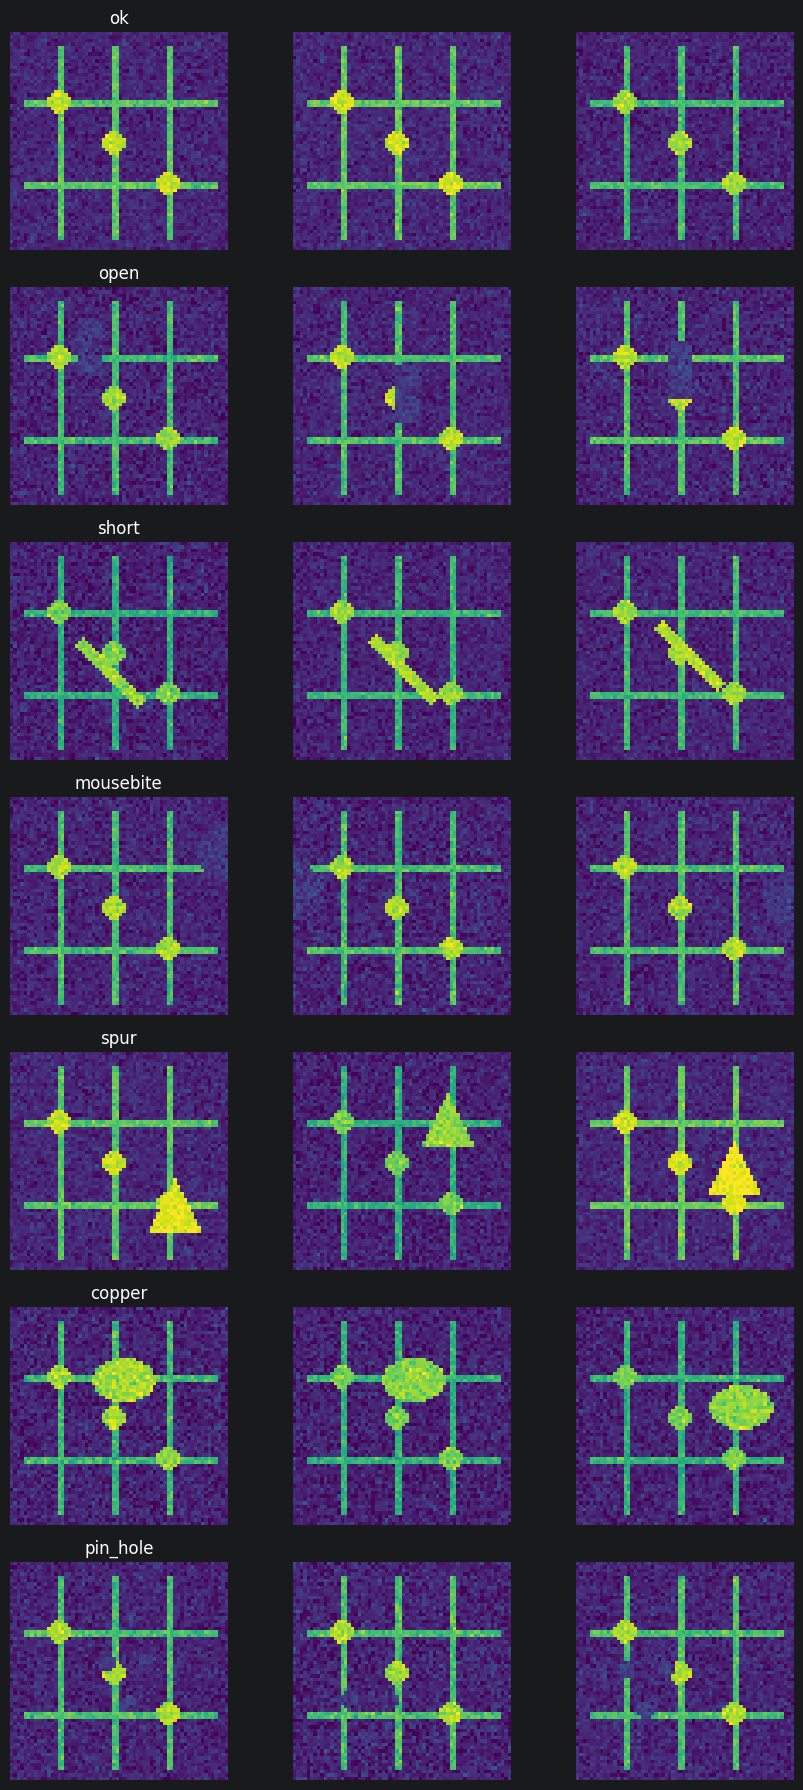

In [14]:
# TODO — 3 exemples par classe en grille 7×3
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 18))

for i, cls in enumerate(CLASSES):
    images = list((DATA_DIR / cls).glob("*.png"))[:3]

    for j, img_path in enumerate(images):
        img = Image.open(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

In [13]:
# TODO — entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?